# Complement · Anàlisi univariant

[Obre aquest quadern a Google Colab](https://colab.research.google.com/github/mlacasa/1BATXILLERAT/blob/main/An%C3%A1lisisUnivariante%28I%29.ipynb)

**Matemàtiques · 1r de batxillerat**  
**Autoria: Dr. Lacasa-Cazcarra · Any 2026**

**Objectiu.** Construir taules i gràfiques coherents i interpretar dades numèriques i ordinals.

**Abans de començar:** freqüències, mitjana i mediana  
**Temps orientatiu:** 1–2 sessions. Hi ha activitats bàsiques i ampliacions opcionals.

**Funcionament.** Executa les cel·les en ordre, des del començament. Primer fes una predicció,
després experimenta i escriu una justificació. Els controls són opcionals: també pots
modificar els arguments de les funcions i executar-les. Les figures representen mostres
finites; les propietats infinites necessiten una demostració.

**Procedència.** Reelaboració d'AnálisisUnivariante(I).ipynb; dades simulades amb llavor fixa.


In [1]:
import math
from fractions import Fraction
from decimal import Decimal, localcontext
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True,
                     "font.size": 11, "figure.dpi": 100})

def explora(funcio, **rangs):
    """Controls opcionals: la mateixa funció també es pot cridar directament."""
    # Conservem un exemple estàtic per als lectors sense controls interactius.
    funcio()
    try:
        import ipywidgets as widgets
    except ImportError:
        print("Sense controls: executem els paràmetres per defecte. Pots canviar-los a la crida.")
        return None
    panell = widgets.interactive(funcio, **rangs)
    display(panell)
    return panell


## Ruta guiada per a 1r de batxillerat

**Pregunta de partida:** Una mitjana més alta vol dir que gairebé tots els valors han augmentat?

**Al final ho has de poder explicar:** Interpretar com un valor extrem modifica la mitjana, la mediana i la forma d'una distribució.

La primera lectura combina l'exemple resolt amb el **laboratori animat** i les preguntes
que l'acompanyen. Els apartats marcats com a ampliació formal aprofundeixen en el rigor;
no cal entendre tot el codi per interpretar la matemàtica.

Dedica 2 minuts a una predicció escrita, 8–10 minuts a experimentar i pausar,
i 5 minuts a justificar una conclusió amb càlculs. Després resol el repte amb dades noves.
L'animació té controls de reproducció, pausa i selecció de fotograma.
Si el visor no mostra HTML interactiu, el fotograma estàtic i la funció
`fotograma_laboratori(...)` permeten fer la mateixa activitat pas a pas després d'executar el codi.


## 1. Dades i freqüències
Una variable discreta pren valors aïllats (no necessàriament enters); una variable
contínua pot prendre qualsevol valor d'un interval en el model matemàtic.
Les dades següents són edats enteres **simulades**, no una mostra real d'alumnes.

Per als intervals usem [a,b), excepte l'últim, que inclou també el màxim.
La taula i l'histograma han de fer servir exactament les mateixes vores.


,Interval,Freqüència,Freqüència relativa,Acumulada
0,"[18, 24.71)",9,0.09,9
1,"[24.71, 31.43)",17,0.17,26
2,"[31.43, 38.14)",18,0.18,44
3,"[38.14, 44.86)",14,0.14,58
4,"[44.86, 51.57)",18,0.18,76
5,"[51.57, 58.29)",12,0.12,88
6,"[58.29, 65]",12,0.12,100


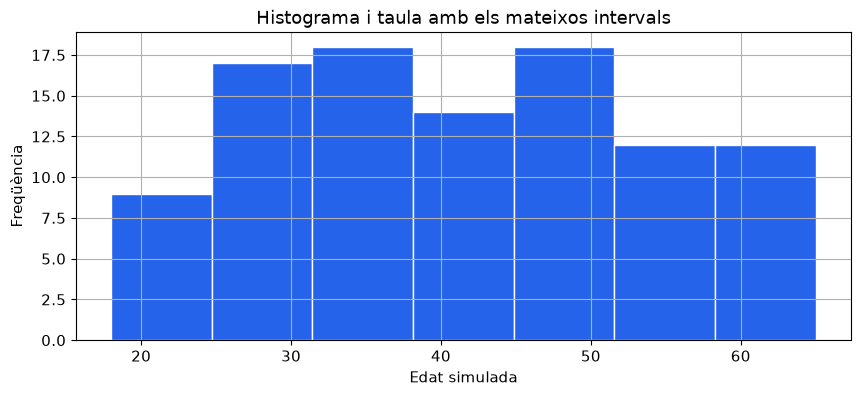

Total comptat: 100 de 100


interactive(children=(IntSlider(value=7, description='classes', max=15, min=1), Output()), _dom_classes=('widg…

In [2]:
import pandas as pd

rng = np.random.default_rng(2026)
edats = rng.integers(18, 66, size=100)

def taula_frequencies(dades, classes=7):
    dades = np.asarray(dades, dtype=float)
    if dades.ndim != 1 or dades.size == 0 or not np.isfinite(dades).all():
        raise ValueError("Cal un vector no buit de nombres finits.")
    if not isinstance(classes, int) or classes < 1:
        raise ValueError("El nombre de classes ha de ser un enter positiu.")
    freq, vores = np.histogram(dades, bins=classes)
    intervals = [f"[{a:.4g}, {b:.4g}{']' if i == len(freq)-1 else ')'}"
                 for i, (a, b) in enumerate(zip(vores[:-1], vores[1:]))]
    taula = pd.DataFrame({"Interval": intervals, "Freqüència": freq,
                          "Freqüència relativa": freq/len(dades),
                          "Acumulada": np.cumsum(freq)})
    return taula, vores

def histograma(classes=7):
    taula, vores = taula_frequencies(edats, classes)
    display(taula)
    fig, ax = plt.subplots()
    ax.hist(edats, bins=vores, edgecolor="white", color="#2563eb")
    ax.set(xlabel="Edat simulada", ylabel="Freqüència", title="Histograma i taula amb els mateixos intervals")
    plt.show()
    print("Total comptat:", int(taula["Freqüència"].sum()), "de", len(edats))
panell = explora(histograma, classes=(1, 15, 1))


## Laboratori animat · observa, atura i explica


### Canviem una sola dada: què explica cada resum?

Treballem amb **21 temps sintètics** de desplaçament a classe, en minuts.
Vint es mantenen fixos; només canviem el més gran, de 15 a 60 minuts.
No són dades recollides d'alumnes reals.

- La **mitjana** reparteix la suma entre totes les observacions: qualsevol canvi hi influeix.
- La **mediana** és el valor central després d'ordenar: amb 21 dades, la posició és l'11a.
- El **diagrama de caixa** situa mediana, quartils i possibles valors atípics.
  El criteri d'1,5 vegades el recorregut interquartílic marca valors per revisar, no errors automàtics.

L'histograma conserva els mateixos intervals, eixos i nombre de dades en tots els fotogrames.
Així els canvis visuals corresponen a les dades, no a un canvi d'escala.

**Prediu.** Si l'única dada modificada augmenta 21 minuts, quant pujarà la mitjana?
**Pausa** i comprova si s'ha mogut la mediana. Quantes persones han canviat el temps de trajecte?


In [3]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def fotograma_laboratori(pas):
    """Mostra un estat quiet per poder llegir, dibuixar i prendre apunts."""
    fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.7), dpi=90)
    dibuixa_laboratori(pas, axes)
    fig.suptitle(titol_laboratori, fontsize=14, weight="bold")
    fig.tight_layout(rect=(0, 0, 1, .92))
    plt.show()

def anima_laboratori():
    """Animació HTML amb pausa i desplaçament manual; no necessita FFmpeg."""
    fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.7), dpi=80)
    def actualitza(pas):
        for ax in axes:
            ax.clear()
        dibuixa_laboratori(pas, axes)
        fig.suptitle(titol_laboratori, fontsize=14, weight="bold")
        fig.tight_layout(rect=(0, 0, 1, .92))
    animacio = FuncAnimation(fig, actualitza, frames=fotogrames_laboratori,
                             interval=700, repeat=False, cache_frame_data=False)
    try:
        contingut = animacio.to_jshtml(fps=1.5, default_mode="once")
    finally:
        plt.close(fig)
    return HTML(contingut)


In [4]:
titol_laboratori = "Una dada extrema: mitjana i mediana no expliquen el mateix"
from inspect import signature
temps_fixos = np.array([8, 9, 9, 10, 10, 10, 11, 11, 11, 12,
                       12, 12, 12, 13, 13, 13, 14, 14, 14, 15], dtype=float)
fotogrames_laboratori = list(range(16))

def resum_temps(valor):
    dades = np.append(temps_fixos, valor)
    return dades, float(np.mean(dades)), float(np.median(dades))

def dibuixa_laboratori(pas, axes):
    valor = 15+3*pas
    dades, mitjana, mediana = resum_temps(valor)
    ax, bx = axes
    ax.hist(dades, bins=np.arange(5, 66, 5), color="#bfdbfe", edgecolor="#2563eb")
    ax.axvline(mitjana, color="#ea580c", lw=2, label=f"Mitjana: {mitjana:.2f}")
    ax.axvline(mediana, color="#047857", lw=2, ls="--", label=f"Mediana: {mediana:.2f}")
    ax.set(xlim=(5, 65), ylim=(0, 18), xlabel="Temps (minuts)", ylabel="Freqüència absoluta",
           title=f"21 observacions; només en canvia una\nValor modificat: {valor} minuts")
    ax.legend(fontsize=8)
    orientacio = ({"orientation": "horizontal"} if "orientation" in signature(bx.boxplot).parameters
                  else {"vert": False})
    bx.boxplot(dades, **orientacio, widths=.35, patch_artist=True,
               boxprops=dict(facecolor="#ddd6fe"), medianprops=dict(color="#047857", linewidth=2))
    bx.scatter([valor], [.65], color="#ea580c", s=55, label="Dada que modifiquem")
    bx.set(xlim=(5, 65), ylim=(.45, 1.5), yticks=[], xlabel="Temps (minuts)",
           title="Mateixa escala que l'histograma\nEls punts separats són possibles valors atípics")
    bx.legend(fontsize=8, loc="upper right")


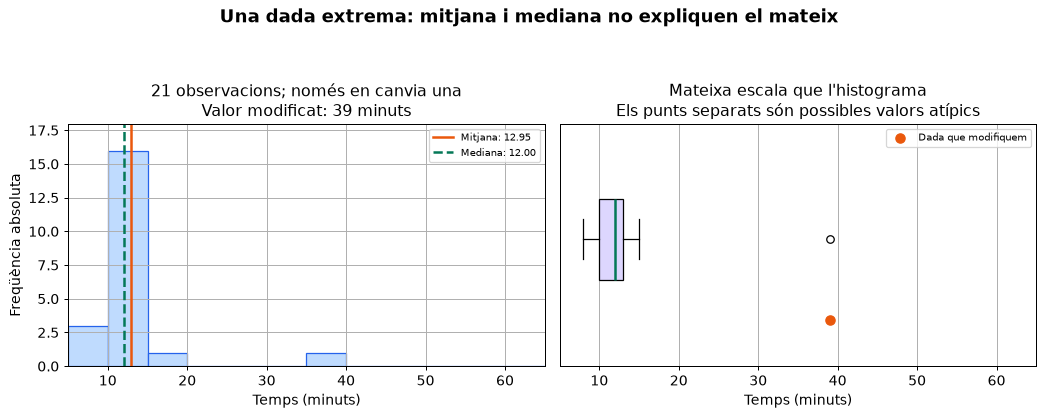

In [5]:
# Fotograma visible també quan no es reprodueix l'animació.
fotograma_laboratori(fotogrames_laboratori[len(fotogrames_laboratori)//2])


**Ara reprodueix l'animació.** Fes servir la pausa i el control de fotograma per contrastar la teva predicció. Els valors numèrics dels títols formen part de l'explicació.


In [6]:
display(anima_laboratori())


### Compara abans de concloure

Compara 15 i 60 minuts per a l'única dada que canvia. Els eixos i les classes es mantenen: anota la variació de mitjana i mediana i explica quantes persones han modificat el temps.

Tria dos estats amb els controls i prem **Compara els estats**. Llegeix les escales: algunes ampliacions del laboratori canvien els límits dels eixos. Justifica la comparació amb els nombres dels títols.


In [7]:
parella_comparacio = (0, 15)
etiquetes_comparacio = [f"Dada modificada: {15+3*k} minuts" for k in fotogrames_laboratori]
preguntes_taller = [{'enunciat': 'Si una sola dada augmenta 21 minuts en una mostra de 21 dades, quant augmenta la mitjana?', 'opcions': ['21 minuts', '1 minut', 'No canvia'], 'correcta': 1, 'retorn': ["Cal repartir l'increment de la suma entre les 21 observacions.", "Correcte: l'increment de la mitjana és 21/21=1 minut.", 'La mitjana depèn de la suma i per tant canvia quan una dada canvia.']}, {'enunciat': 'Quina posició determina la mediana amb 21 dades ordenades?', 'opcions': ['La 11a', 'La 10a', "L'última"], 'correcta': 0, 'retorn': ['Correcte: queden 10 observacions a cada costat.', 'La 10a deixaria 9 observacions abans i 11 després.', "L'última és el màxim, no la mediana."]}, {'enunciat': "Un punt atípic al diagrama de caixa s'ha d'eliminar sempre?", 'opcions': ['Sí, perquè és un error', 'Sí, si augmenta la mitjana', 'No: cal investigar-ne el context i la qualitat'], 'correcta': 2, 'retorn': ['Un valor poc habitual pot ser real; atípic no vol dir erroni.', "L'efecte sobre la mitjana no justifica esborrar una observació.", 'Correcte: revisem unitats, registre i context abans de decidir.']}]


In [8]:
def compara_estats(inicial, final):
    """Dos fotogrames simultanis; els eixos conserven el significat del laboratori."""
    if inicial not in fotogrames_laboratori or final not in fotogrames_laboratori:
        raise ValueError("Tria dos estats de fotogrames_laboratori.")
    fig, axes = plt.subplots(2, 2, figsize=(11.6, 8.8), dpi=90)
    for fila, estat, lletra in [(0, inicial, "A"), (1, final, "B")]:
        dibuixa_laboratori(estat, axes[fila])
        for ax in axes[fila]:
            ax.set_title(lletra + " · " + ax.get_title(), fontsize=10)
    fig.suptitle("Comparació simultània: observa què canvia i què es conserva", fontsize=14, weight="bold")
    fig.tight_layout(rect=(0, 0, 1, .95), h_pad=3)
    plt.show()

def controls_comparacio():
    try:
        import ipywidgets as widgets
    except ImportError:
        print("Canvia els dos arguments de compara_estats(...) per fer una altra comparació.")
        return None
    opcions = list(zip(etiquetes_comparacio, fotogrames_laboratori))
    panell = widgets.interactive(compara_estats, {"manual": True, "manual_name": "Compara els estats"},
        inicial=widgets.Dropdown(options=opcions, value=parella_comparacio[0], description="Estat A:"),
        final=widgets.Dropdown(options=opcions, value=parella_comparacio[1], description="Estat B:"))
    display(panell)
    return panell

def feedback_resposta(numero, lletra):
    """Retorn per opció. Ex.: feedback_resposta(1, 'B'); no desa ni envia respostes."""
    if isinstance(numero, bool) or not isinstance(numero, int) or not 1 <= numero <= len(preguntes_taller):
        raise ValueError("El número de pregunta no és vàlid.")
    q = preguntes_taller[numero-1]
    lletra = str(lletra).strip().upper()
    lletres = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"[:len(q["opcions"])]
    if lletra not in lletres or len(lletra) != 1:
        raise ValueError("Tria una de les lletres de les opcions.")
    index = lletres.index(lletra)
    return {"correcte": index == q["correcta"], "explicacio": q["retorn"][index]}

def mostra_feedback(numero, lletra):
    resultat = feedback_resposta(numero, lletra)
    estat = "Resposta encertada" if resultat["correcte"] else "Revisa el raonament"
    display(Markdown(f"**Pregunta {numero} · {estat}.** {resultat['explicacio']}"))
    return resultat

def crea_autoavaluacio():
    try:
        import ipywidgets as widgets
        from html import escape
    except ImportError:
        print("Respon amb mostra_feedback(1, 'A'), canviant la pregunta i la lletra.")
        return None
    camps, selectors = [], []
    for numero, q in enumerate(preguntes_taller, 1):
        opcions = [("Tria una resposta", None)] + [
            (f"{chr(65+k)}. {text}", chr(65+k)) for k, text in enumerate(q["opcions"])]
        selector = widgets.Dropdown(options=opcions, value=None, layout=widgets.Layout(width="100%"))
        selectors.append(selector)
        camps.append(widgets.VBox([
            widgets.HTML(f"<b>{numero}. {escape(q['enunciat'])}</b>"), selector]))
    sortida = widgets.Output()
    boto = widgets.Button(description="Comprova i raona", button_style="info", layout=widgets.Layout(width="180px"))
    def comprova(_):
        with sortida:
            sortida.clear_output(wait=True)
            for numero, selector in enumerate(selectors, 1):
                if selector.value is None:
                    display(Markdown(f"**Pregunta {numero}:** encara has de triar una resposta."))
                else:
                    mostra_feedback(numero, selector.value)
    def canvi(_):
        sortida.clear_output()
    for selector in selectors:
        selector.observe(canvi, names="value")
    boto.on_click(comprova)
    panell = widgets.VBox(camps+[boto, sortida])
    display(panell)
    return {"panell": panell, "selectors": selectors, "boto": boto, "sortida": sortida}


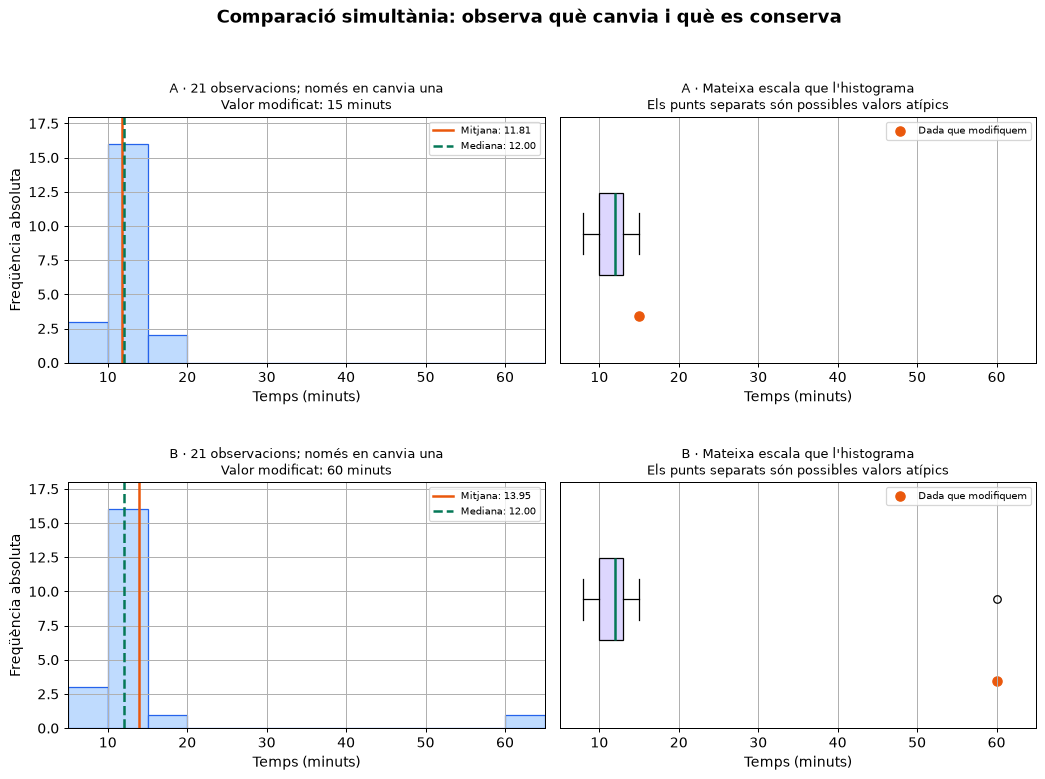

interactive(children=(Dropdown(description='Estat A:', options=(('Dada modificada: 15 minuts', 0), ('Dada modi…

In [9]:
compara_estats(*parella_comparacio)
panell_comparacio = controls_comparacio()


### Taller de Python · canvia una dada i explica l'efecte

Representa totes les observacions com a punts, ordenades de menor a major. Canvia el valor extrem i identifica la posició central: és l'11a, perquè hi ha 21 dades. Compara aquesta lectura amb l'histograma.

**Fes-ho en tres passos:** escriu una predicció, modifica les dades indicades i contrasta el resultat. Acaba amb una explicació matemàtica; executar la cel·la és només una part de la tasca.


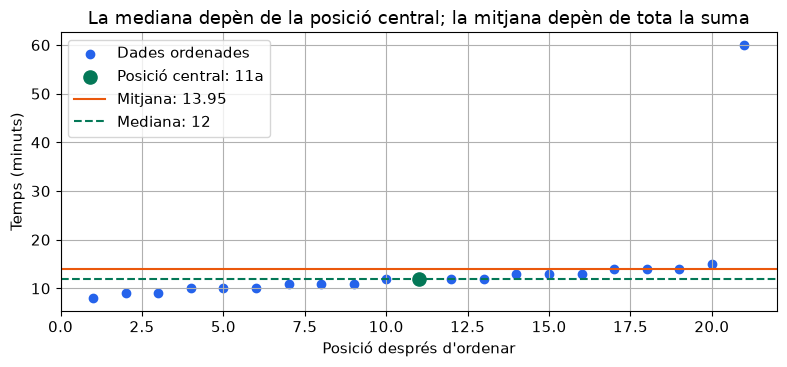

In [10]:
valor_extrem_taller = 60
dades_taller, mitjana_taller, mediana_taller = resum_temps(valor_extrem_taller)
ordenades = np.sort(dades_taller)
posicions = np.arange(1, len(ordenades)+1)
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.scatter(posicions, ordenades, color="#2563eb", label="Dades ordenades")
ax.scatter([11], [ordenades[10]], color="#047857", s=90, zorder=5, label="Posició central: 11a")
ax.axhline(mitjana_taller, color="#ea580c", label=f"Mitjana: {mitjana_taller:.2f}")
ax.axhline(mediana_taller, color="#047857", ls="--", label=f"Mediana: {mediana_taller:g}")
ax.set(xlabel="Posició després d'ordenar", ylabel="Temps (minuts)",
       title="La mediana depèn de la posició central; la mitjana depèn de tota la suma")
ax.legend(); plt.tight_layout(); plt.show()


### Atura't i comprova què has entès

Tria una resposta per pregunta i escriu una justificació abans de comprovar-la. Si t'equivoques, llegeix el retorn i torna al gràfic per localitzar el malentès.

**1. Si una sola dada augmenta 21 minuts en una mostra de 21 dades, quant augmenta la mitjana?**

- A. 21 minuts
- B. 1 minut
- C. No canvia

**2. Quina posició determina la mediana amb 21 dades ordenades?**

- A. La 11a
- B. La 10a
- C. L'última

**3. Un punt atípic al diagrama de caixa s'ha d'eliminar sempre?**

- A. Sí, perquè és un error
- B. Sí, si augmenta la mitjana
- C. No: cal investigar-ne el context i la qualitat

Si no es mostren els controls, executa `mostra_feedback(1, 'B')`, canviant el número i la lletra. El retorn comprova l'opció; la justificació escrita s'ha de discutir a classe.


In [11]:
autoavaluacio = crea_autoavaluacio()


### Evidència final de l'aprenentatge

Completa aquestes frases amb un cas concret del taller:

1. **He canviat…**
2. **Esperava que… perquè…**
3. **El resultat ha estat…**
4. **Ara ho explico amb aquesta relació o propietat…**
5. **Un cas en què no puc generalitzar directament és…**

Torna a una pregunta que hagis corregit i explica què has canviat del teu raonament.


### Investiga i transfereix


1. Calcula quant puja la mitjana quan la dada passa de 15 a 60. Comprova que no necessites tornar a sumar-ho tot.
2. Per a una notícia sobre el trajecte «típic», quin resum destacaries en aquest exemple? Justifica-ho amb les dades.
3. És correcte esborrar una dada només perquè apareix com a atípica? Què comprovaries abans?
4. Canvia el nombre de classes de l'histograma original. Què canvia visualment i què es manté en les dades?


### El teu raonament

Edita aquesta cel·la per deixar evidència del que has après.

- **Abans pensava que…**
- **He provat aquests valors…**
- **Al gràfic he observat…**
- **Ho justifico amb aquest càlcul o propietat…**
- **La meva conclusió i el seu límit són…**

No n'hi ha prou amb una captura: relaciona el dibuix, els nombres i l'explicació.


In [12]:
# Espai per al teu experiment: canvia l'índex i executa la cel·la.
# fotograma_laboratori(fotogrames_laboratori[0])
# Escriu aquí els càlculs del repte.


<details><summary>Comprovació: obre-la després d'intentar els reptes</summary>

La mitjana puja (60−15)/21=15/7≈2,142857 minuts. La mediana es manté en 12.
En aquesta mostra la mediana descriu millor la posició central sense arrossegar-se pel valor extrem,
però convé informar també de la dispersió. Cal revisar unitats, transcripció i context abans
d'eliminar observacions. Canviar classes modifica la representació, no les dades ni la seva mitjana.

</details>

**Comprova el teu aprenentatge:** has interpretat els eixos i les unitats, justificat una predicció amb un càlcul i aplicat la idea a un cas nou? Una observació finita pot suggerir una propietat; una afirmació general necessita una justificació.


## 2. Diagrama de caixa i valors atípics
Separem els conjunts de dades amb noms diferents, perquè executar una activitat
no substitueixi les dades necessàries per a una altra.
Per defecte, els bigotis arriben a les dades més extremes dins de les tanques
$Q_1-1,5\,IQR$ i $Q_3+1,5\,IQR$, amb $IQR=Q_3-Q_1$.
No cal que acabin exactament a les tanques. Un valor atípic no és necessàriament un error.


,Edat,Salari
count,5.000000,5.000000
mean,30.600000,70000.000000
std,7.021396,15811.388301
min,23.000000,50000.000000
25%,25.000000,60000.000000
50%,30.000000,70000.000000
75%,35.000000,80000.000000
max,40.000000,90000.000000


describe() calcula la desviació estàndard mostral (divisor n−1).


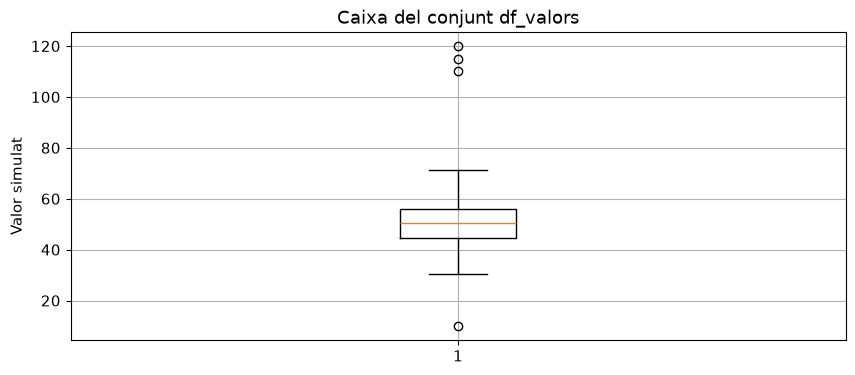

Valors fora de les tanques: [ 10. 110. 115. 120.]


In [13]:
rng_caixa = np.random.default_rng(42)
valors = np.concatenate([rng_caixa.normal(50, 10, 100), [10, 110, 115, 120]])
df_valors = pd.DataFrame({"Valors": valors})
df_persones = pd.DataFrame({"Edat": [23, 25, 35, 30, 40], "Salari": [50000, 60000, 80000, 70000, 90000]})
display(df_persones.describe())
print("describe() calcula la desviació estàndard mostral (divisor n−1).")
fig, ax = plt.subplots()
ax.boxplot(df_valors["Valors"])
ax.set(ylabel="Valor simulat", title="Caixa del conjunt df_valors")
plt.show()
q1, q3 = np.quantile(valors, [.25, .75])
iqr = q3-q1
print("Valors fora de les tanques:", valors[(valors < q1-1.5*iqr) | (valors > q3+1.5*iqr)])


## 3. Categories ordinals
En una variable ordinal importa conservar l'ordre de les categories.
Els gràfics han d'utilitzar les dades estudiades, fins i tot si demanem ajuda a una IA
per escriure el codi. No substituïm les observacions per nombres inventats sense indicar-ho.


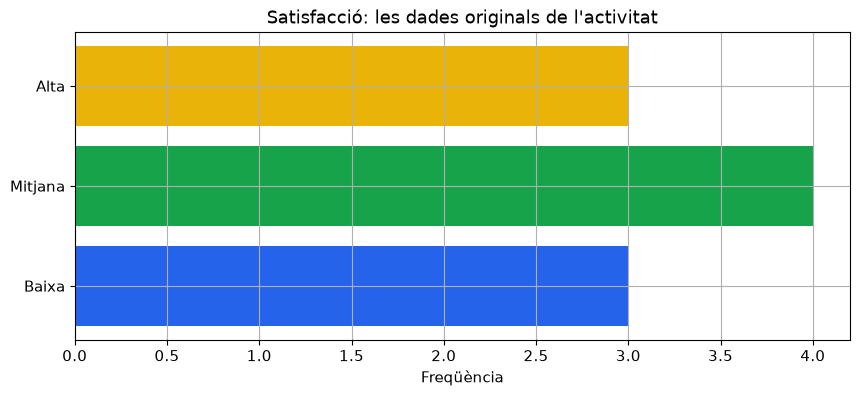

In [14]:
ordre = ["Baixa", "Mitjana", "Alta"]
satisfaccio = pd.Series(pd.Categorical(
    ["Baixa", "Mitjana", "Alta", "Baixa", "Mitjana", "Alta", "Alta", "Mitjana", "Baixa", "Mitjana"],
    categories=ordre, ordered=True))
recomptes = satisfaccio.value_counts(sort=False).reindex(ordre, fill_value=0)
fig, ax = plt.subplots()
ax.barh(ordre, recomptes.to_numpy(), color=["#2563eb", "#16a34a", "#eab308"])
ax.set(xlabel="Freqüència", title="Satisfacció: les dades originals de l'activitat")
plt.show()


## Activitats
1. Canvia el nombre de classes. Canvien les dades o només l'agrupació?
2. Executa `taula_frequencies([18,19,20], 2)` i `taula_frequencies([20,20,20], 2)`.
   Comprova que sempre es compten les tres observacions.
3. Per què no podem concloure que tots els valors atípics són errors de mesura?
4. Redacta una interpretació del gràfic ordinal que coincideixi amb els recomptes.

<details><summary>Comprovació</summary>

Canvia l'agrupació, no les dades. Les freqüències ordinals són 3, 4 i 3.
Cal investigar el context abans de decidir si un valor atípic és un error.
</details>


**Navegació:** [Índex i guia](README.md)
